# Objectif 


L'objectif est d'établir une formulation analytique du vecteur de RTF noté $\mathbf{\Pi}$ dans le cadre de la théorie des modes normaux.

\subsubsection{Hypothèses et cadre de travail}

* L'antenne est composée de M capteurs.
* La position des capteurs de l'antenne est notée $\mathbf{x_j}=(r_j, z_j)$.
* La source est positionnée sur l'axe z $\mathbf{x_s}=(0, z_s)$.
* L'environnement est axisymétrique.

## Formulation du problème

On pose 
$$
    Q =  \frac{e^{i3\pi/4}}{\rho(z_s) \sqrt{8 \pi}}
$$

et

$$
    A_m(z) = \Psi_m(z_{s}) \Psi_m(z) \frac{1}{\sqrt{k_{rm}}}
$$

La fonction de transfert du guide d'onde s'écrit,

$$
    H(f, r, z) = \frac{Q}{\sqrt{r}} \sum_{m=1}^{\infty} A_m(z) e^{-ik_{rm}
    r}
$$

En particulier, la fonction de transfert du canal de propagation associée au récepteur $j$ est :

$$
    H_{j} = \frac{Q}{\sqrt{r_j}} \sum_{m=1}**{\infty} A_m(z_j) e^{-ik_{rm}
    r_{j}}
$$

on s'intéresse au vecteur de RTF défini par

$$
    \mathbf{\Pi} \overset{\Delta}{=}
    \left [ \frac{H_{1}}{H_{1}} \, \frac{H_{2}}{H_{1}} \, \dots \, \frac{H_{M}}{H_{1}} \right ]^T
    = \frac{1}{H_{1}} \mathbf{H}
$$

En particulier, il s'agira d'étudier le comportement d'une composante du vecteur $\mathbf{\Pi}$,

$$
    \Pi_j = \frac{H_j}{H_1}, \quad j \in [1, J]
$$

## Approche calcul 

$$
I(r, z) = \frac{\tilde{Q}}{r} \left [  \sum_{m=1}^{\infty} A_m^2 + \sum_{m=1}^{\infty} \sum_{n>m}^{\infty} 2 A_m A_n \cos{\Delta k_{mn} r} \right ]
$$

On pose, 

$$
\gamma : r \mapsto \lvert \Pi_j(r, z) \rvert^2
$$

ie, 

$$
 \gamma(r) =  \frac{I(r_j, z)}{I(r_1, z)}
$$

En appliquant les règles de dérivation élémentaires,

$$
    \gamma'(r) = \frac{1}{I(r, z)^2} \left [I(r, z) \frac{\partial }{\partial r} I(r + d_j, z) - I(r + d_j, z)  \frac{\partial }{\partial r} I(r, z) \right ]
$$

$$
\frac{\partial }{\partial r} I(r, z) = \frac{-1}{r} \left [ I(r, z) + \tilde{Q} \sum_{m=1}^{\infty} \sum_{n>m}^{\infty} 2 A_m A_n \Delta k_{mn} \sin{\Delta k_{mn} r}\right ]
$$

## Cas étudié : antenne linéaire horizontale dans un guide d'onde isocélère avec une interface fond parfaitement solide 

**Conditions aux limites (cas parfaitement solide -> perfectly_rigid) **

Pression nulle en surface et au fond :
$$
p(r, z=0) = 0 \quad \text{et} \quad \frac{\partial p(r, z)}{\partial z} \rvert_{z=D} = 0 
$$

et les fonctions modales s'écrivent 

$$
\Psi_m(z) = \sqrt{\frac{2 \rho}{D}} \sin(k_{zm} z)
$$

Les fonctions $\Psi_m$ sont les fonctions propres associées aux valeurs propres $k_{rm}$,

$$
    k_{rm} = \sqrt{ k^2 - k_{zm}^2}
$$

avec, 

$$ 
k_{zm} =  (m - \frac{1}{2}) \frac{\pi}{D}, \quad m \in \mathbb{N}^{*} .
$$
           


**Conditions aux limites (cas parfaitement réfléchissant -> pressure release) **

Pression nulle en surface et au fond :
$$
p(r, z=0) = p(r, z=D) = 0 
$$

et les fonctions modales s'écrivent 

$$
\Psi_m(z) = \sqrt{\frac{2 \rho}{D}} \sin(k_{zm} z)
$$

Les fonctions $\Psi_m$ sont les fonctions propres associées aux valeurs propres $k_{rm}$,

$$
    k_{rm} = \sqrt{ k^2 - k_{zm}^2}
$$

avec, 

$$ 
k_{zm} =  \frac{m\pi}{D}, \quad m \in \mathbb{N}^{*} .
$$
           

In [1]:
import os
import sys
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

from scipy.fft import rfft, rfftfreq
from scipy.signal import find_peaks

sys.path.append(r"C:\Users\baptiste.menetrier\Desktop\devPy\phd")

from propa.ideal_waveguide import (
    kr,
    psi,
    psi_normalised,
    h,
    field,
    plot_tl,
    nb_propagating_modes,
    intensity,
    intensity_1,
)


import source.global_constants as g
from publication.publication_figure import PubFigure, LargeFigure, SmallFigure, color

In [2]:
# Define usefull paths 
current_dir = os.getcwd()
print(f"Current directory: {current_dir}")
img_dir = os.path.join(current_dir, "img")
if not os.path.exists(img_dir):
    os.makedirs(img_dir)
    print(f"Created directory: {img_dir}")

Current directory: c:\Users\baptiste.menetrier\Desktop\devPy\phd\illustration\general_ocean_acoustics\modal_theory\rtf_modal_theory


# Etape 1 : définition du guide d'onde parfait et illustration de quelques propriétés 

### Paramètres du problème

In [3]:
# Parameters
D = 100 # Depth of the waveguide
# Receiver
z_rcv = 50 # Depth of receiver
# Source
z_src= 25 # Depth of source 
# Signal
f0 = 100 # Frequency in Hz
# bottom_bc = 'pressure_release' # Bottom boundary condition
bottom_bc = "perfectly_rigid"  # Bottom boundary condition

# TL grid properties
ngrid = 1000 # Number of grid points along each dimension
rmax = 50 * 1e3 # Maximum range in m
r_grid = np.linspace(1, rmax, ngrid)
z_grid = np.linspace(0, D, ngrid)
rr, zz = np.meshgrid(r_grid, z_grid)

# Étape 2 : étude du rapport des fonctions de transfert
L'objectif ici est d'étudier les variations spatiales du rapport des fonctions de transfert et de guider le calcul analytique. Dans un premier temps :

* la fréquence f est fixée
* l'immersion de la source est fixée
* l'antenne est linéaire horizontale 

Ainsi, il s'agit d'étudier les variations du rapport de deux fonctions de transfert en fonctions de la distance $r$ de la source au premier capteur de l'antenne (pris pour référence). On s'intérèsse au rapport : 

$$ 
\Pi_{12}(r, z) = \frac{H(r + d_2, z)}{H(r, z)}
$$

Les notations utilisées correspondant aux notations introduites et schématisées dans la note de calcul du même nom que ce notebook. 

In [4]:
def lambda_rm(f, m):
    k_rm = kr(m, f, depth=D, bottom_bc=bottom_bc)
    lambda_m = 2 * np.pi / k_rm
    return lambda_m

## Étude à la fréquence f0 = 100 Hz 

In [5]:
# Parameters
d12 = 10  # Distance between receiver 1 and 2 in m
z_antenna = 50 # Depth of the antenna in m

# Define range vectors
nrgrid = 4000
rmin = 40 * 1e3
rmax = 60 * 1e3
r_grid = np.linspace(rmin, rmax, nrgrid)
r_grid1 = r_grid
r_grid2 = r_grid + d12

# Define z vectors
nzgrid = 400
z_grid = np.linspace(0, D, nzgrid)
rr1, zz1 = np.meshgrid(r_grid, z_grid)
rr2, zz2 = np.meshgrid(r_grid2, z_grid)

In [6]:
# Number of modes to consider (e.g 3 means first three modes)
modes = [1, 2, 3, 4, 5]

abcd_labels = ["a", "b", "c", "d", "e", "f", "g", "h", "i", "j", "k", "l"]

In [7]:
# Compute RTF on the whole grid for a different number of modes
def pi_12_modes(f, z_antenna, z_grid, r_grid, d12, depth, bottom_bc, modes):
    r_grid1 = r_grid
    r_grid2 = r_grid + d12
    pi_12 = []
    for n in modes:
        ff, rr, zz, p_field1 = field(
            f=f, z_src=z_antenna, z=z_grid, r=r_grid1, depth=depth, bottom_bc=bottom_bc, n=n
        )
        ff, _, _, p_field2 = field(
            f=f,
            z_src=z_antenna,
            z=z_grid,
            r=r_grid2,
            depth=depth,
            bottom_bc=bottom_bc,
            n=n,
        )
        p_field2[(p_field2 == 0) | np.isnan(p_field2)] = 1e-20
        p_field1[(p_field1 == 0) | np.isnan(p_field1)] = 1e-20
        pi_12.append(p_field2 / p_field1)
    pi_12 = np.array(pi_12)
    pi_12 = np.squeeze(pi_12)

    return rr, zz, pi_12

In [8]:
# # Compute RTF on the whole grid for a different number of modes
rr, zz, pi_12 = pi_12_modes(
    f=f0,
    z_antenna=z_antenna,
    z_grid=z_grid,
    r_grid=r_grid1,
    d12=d12,
    depth=D,
    bottom_bc=bottom_bc,
    modes=modes,
)

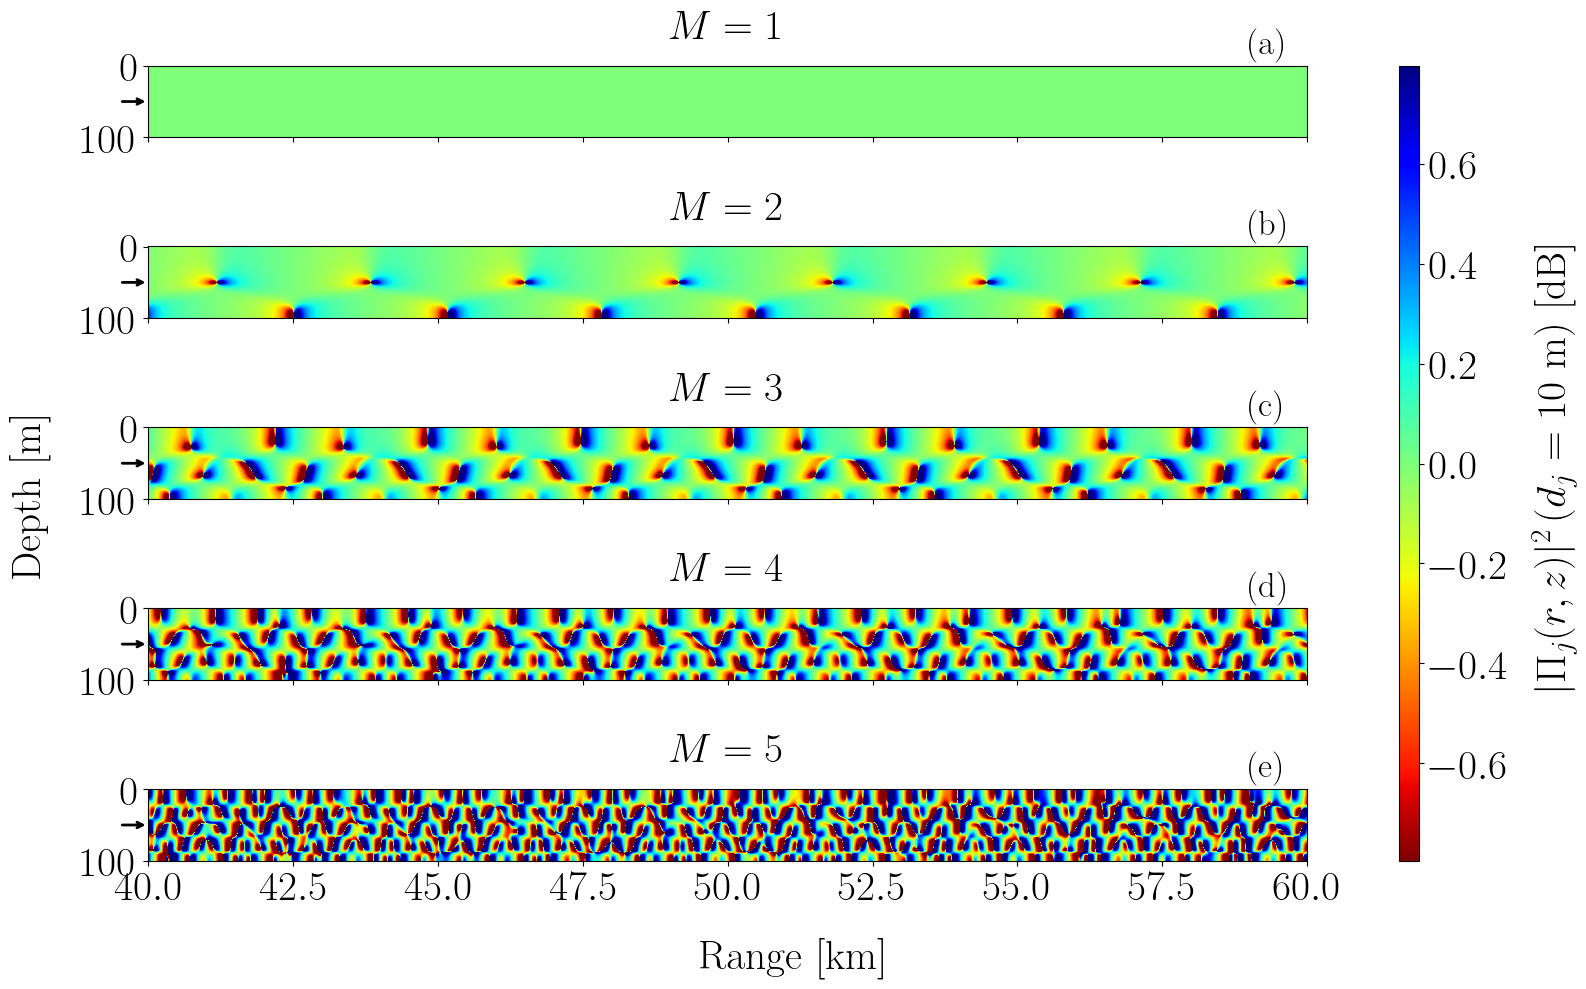

In [9]:
sfig = LargeFigure(size=(16, 10))

pi = 20 * np.log10(np.abs(pi_12))
vmin = np.percentile(pi, 5)
vmax = np.percentile(pi, 95)

fig, axs = plt.subplots(len(modes), sharex=True)
for i_m, m in enumerate(modes):

    # Plot at given number of modes
    title = rf"$M = {{{m}}}$"
    # Plot Pi_j
    im = axs[i_m].pcolormesh(
        rr * 1e-3,
        zz,
        pi[i_m],
        vmin=vmin,
        vmax=vmax,
        cmap="jet_r",
        rasterized=True,
    )
    axs[i_m].invert_yaxis()

    # Add a, b, c labels
    axs[i_m].text(
        0.95,
        1.05,
        f"({abcd_labels[i_m]})",
        transform=axs[i_m].transAxes,
        fontsize=25,
        fontweight="bold",
        va="bottom",
    )
    axs[i_m].set_title(title)

    # Add a black thick arrow to point the depth of the antenna
    axs[i_m].annotate(
        "",
        xy=(np.min(rr) * 1e-3, z_antenna),
        xytext=(np.min(rr) * 1e-3 - 0.5, z_antenna),
        arrowprops=dict(facecolor="black", arrowstyle="->", linewidth=2),
    )

fig.supxlabel("Range [km]")
fig.supylabel("Depth [m]")

# Add common colorbar
cbar = fig.colorbar(im, ax=axs, orientation="vertical", pad=0.05, aspect=40)
cbar.set_label(rf"$\lvert \Pi_j(r, z) \rvert^2 \, (d_j = {{{d12}}}~\textrm{{m}})$  [dB]")

# Save figure
fig_path = os.path.join(
    img_dir,
    f"rtf_pi_rz_dj{d12}m_modes_{'_'.join(map(str, modes))}_f{f0}Hz.png",
)
fig.savefig(fig_path, dpi=300)

#### Impact de la distance inter-capteur $d_j$
L'objectif est d'étudier l'impact de la distance dj entre les deux capteurs sur le rapport des fonctions de transfert 

In [10]:
# Parameters
d12_bis = 250  # New distance between receiver 1 and 2 in m
r_grid2_bis = r_grid + d12_bis

In [11]:
rr, zz, pi_12_bis = pi_12_modes(
    f=f0,
    z_antenna=z_antenna,
    z_grid=z_grid,
    r_grid=r_grid1,
    d12=d12_bis,
    depth=D,
    bottom_bc=bottom_bc,
    modes=modes,
)

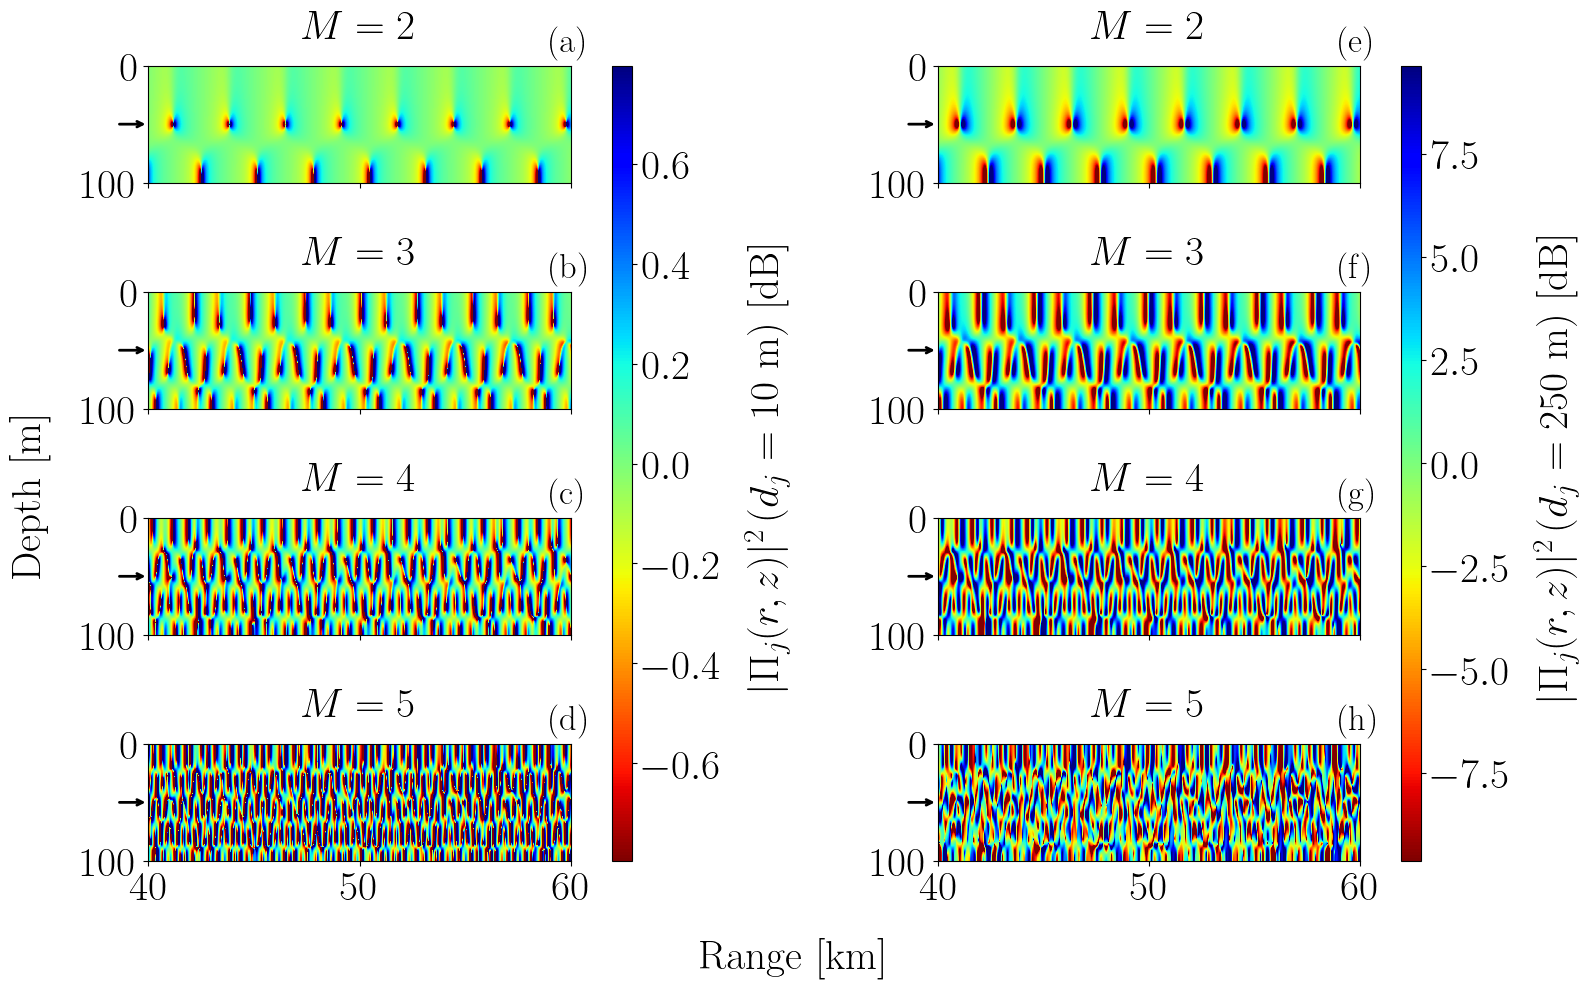

In [12]:
sfig = LargeFigure(size=(16, 10))

pi = 20 * np.log10(np.abs(pi_12))
vmin_1 = np.percentile(pi, 5)
vmax_1 = np.percentile(pi, 95)

pi_bis = 20 * np.log10(np.abs(pi_12_bis))
vmin_2 = np.percentile(pi_bis, 5)
vmax_2 = np.percentile(pi_bis, 95)

modes_to_plot = [2, 3, 4, 5]
fig, axs = plt.subplots(len(modes_to_plot), 2, sharex=True, sharey=False)
i_plot = 0 
for m in modes_to_plot:
    i_m = modes.index(m)

    # Plot at given number of modes
    title = rf"$M = {{{m}}}$"

    im1 = axs[i_plot, 0].pcolormesh(
        rr * 1e-3,
        zz,
        pi[i_m],
        vmin=vmin_1,
        vmax=vmax_1,
        cmap="jet_r",
        rasterized=True,
    )
    axs[i_plot, 0].invert_yaxis()

    im2 = axs[i_plot, 1].pcolormesh(
        rr * 1e-3,
        zz,
        pi_bis[i_m],
        vmin=vmin_2,
        vmax=vmax_2,
        cmap="jet_r",
        rasterized=True,
    )
    axs[i_plot, 1].invert_yaxis()

    # Add a, b, c labels
    axs[i_plot, 0].text(
        0.95,
        1.05,
        f"({abcd_labels[i_plot]})",
        transform=axs[i_plot, 0].transAxes,
        fontsize=25,
        fontweight="bold",
        va="bottom",
    )
    axs[i_plot, 1].text(
        0.95,
        1.05,
        f"({abcd_labels[i_plot + len(modes_to_plot)]})",
        transform=axs[i_plot, 1].transAxes,
        fontsize=25,
        fontweight="bold",
        va="bottom",
    )
    axs[i_plot, 0].set_title(title)
    axs[i_plot, 1].set_title(title)

    # Add a black thick arrow to point the depth of the antenna
    axs[i_plot, 0].annotate(
        "",
        xy=(np.min(rr) * 1e-3, z_antenna),
        xytext=(np.min(rr) * 1e-3 - 1.5, z_antenna),
        arrowprops=dict(facecolor="black", arrowstyle="->", linewidth=2),
    )
    axs[i_plot, 1].annotate(
        "",
        xy=(np.min(rr) * 1e-3, z_antenna),
        xytext=(np.min(rr) * 1e-3 - 1.5, z_antenna),
        arrowprops=dict(facecolor="black", arrowstyle="->", linewidth=2),
    )

    i_plot += 1

# Add colorbar
cbar = fig.colorbar(im1, ax=axs[:, 0], orientation="vertical", pad=0.05, aspect=40)
cbar.set_label(
    rf"$\lvert \Pi_j(r, z) \rvert^2 \, (d_j = {{{d12}}}~\textrm{{m}})$  [dB]"
)
cbar = fig.colorbar(im2, ax=axs[:, 1], orientation="vertical", pad=0.05, aspect=40)
cbar.set_label(
    rf"$\lvert \Pi_j(r, z) \rvert^2 \, (d_j = {{{d12_bis}}}~\textrm{{m}})$  [dB]"
)

fig.supxlabel("Range [km]")
fig.supylabel("Depth [m]")

# Save figure
fig_path = os.path.join(
    img_dir,
    f"comparaison_rtf_pi_rz_dj{d12}m_vs_djbis{d12_bis}m_modes_{'_'.join(map(str, modes_to_plot))}_f{f0}Hz.png",
)
fig.savefig(fig_path, dpi=300)

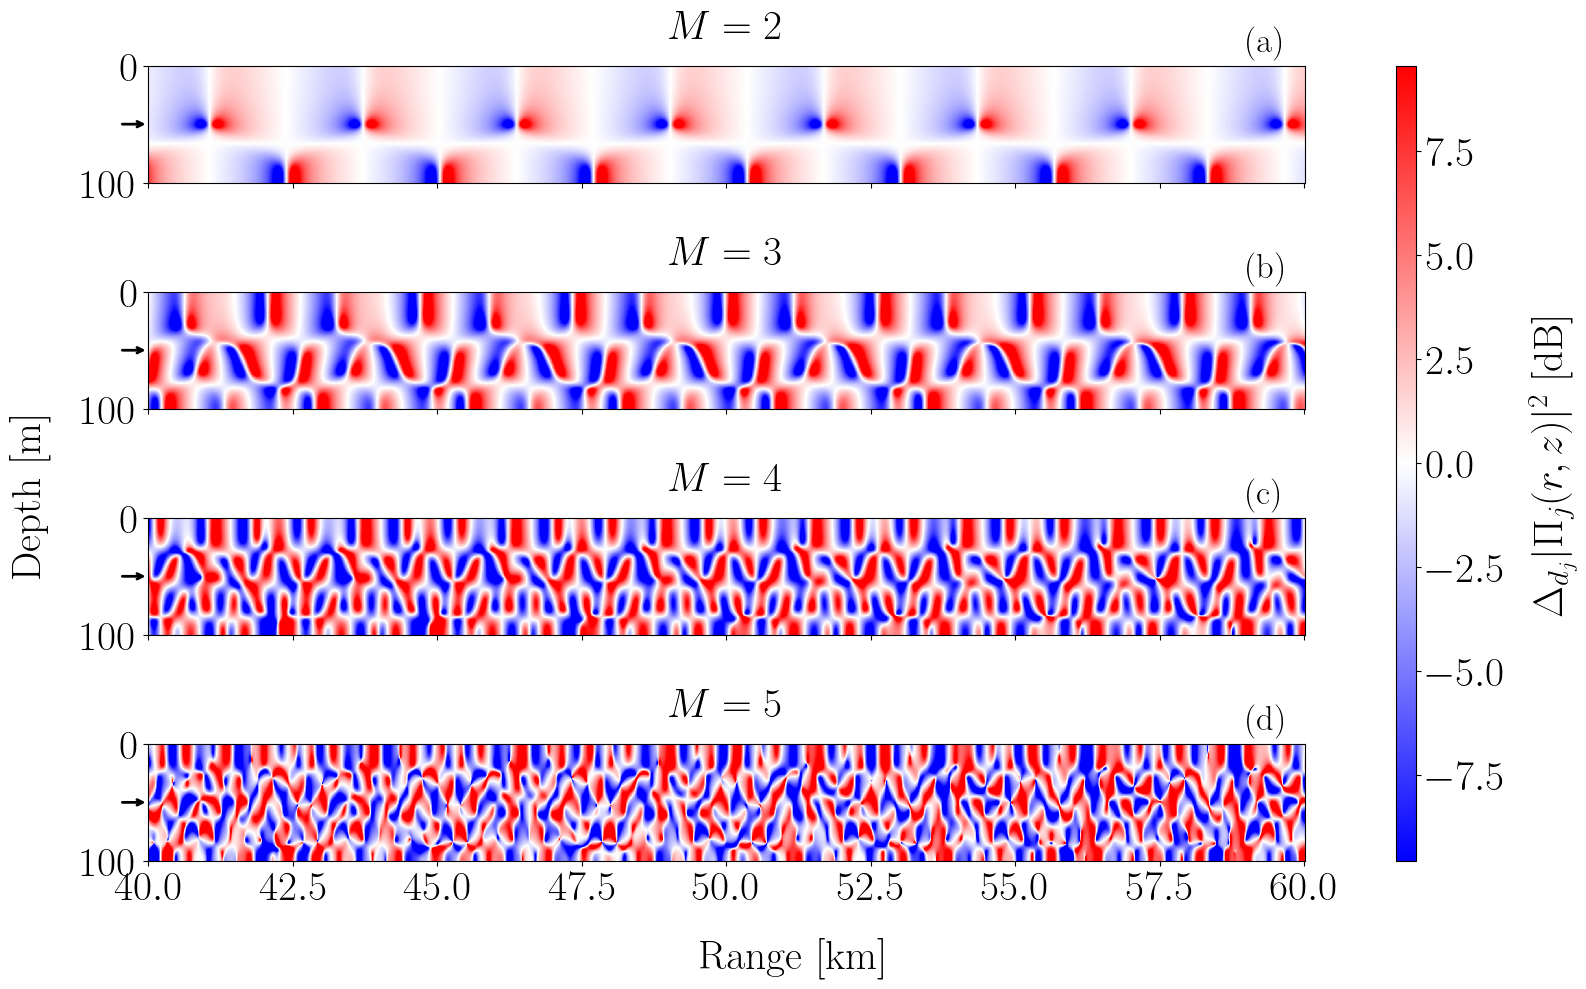

In [13]:
sfig = LargeFigure(size=(16, 10))


pi = 20 * np.log10(np.abs(pi_12))
pi_bis = 20 * np.log10(np.abs(pi_12_bis))
pi_diff = pi_bis - pi

vmin = np.percentile(pi_diff, 5)
vmax = np.percentile(pi_diff, 95)

fig, axs = plt.subplots(len(modes_to_plot), sharex=True, sharey=False)
i_plot = 0
for m in modes_to_plot:
    i_m = modes.index(m)

    # Plot at given number of modes
    title = rf"$M = {{{m}}}$"

    im = axs[i_plot].pcolormesh(
        rr * 1e-3,
        zz,
        pi_diff[i_m],
        vmin=vmin,
        vmax=vmax,
        cmap="bwr",
        rasterized=True,
    )
    axs[i_plot].invert_yaxis()

    # Add a, b, c labels
    axs[i_plot].text(
        0.95,
        1.05,
        f"({abcd_labels[i_plot]})",
        transform=axs[i_plot].transAxes,
        fontsize=25,
        fontweight="bold",
        va="bottom",
    )

    axs[i_plot].set_title(title)

    # Add a black thick arrow to point the depth of the antenna
    axs[i_plot].annotate(
        "",
        xy=(np.min(rr) * 1e-3, z_antenna),
        xytext=(np.min(rr) * 1e-3 - 0.5, z_antenna),
        arrowprops=dict(facecolor="black", arrowstyle="->", linewidth=2),
    )


    i_plot += 1


# Add common colorbar
cbar = fig.colorbar(im, ax=axs, orientation="vertical", pad=0.05, aspect=40)
cbar.set_label(r"$\Delta_{d{_j}} \lvert \Pi_j(r, z) \rvert^2 $ [dB]")

fig.supxlabel("Range [km]")
fig.supylabel("Depth [m]")

# Save figure
fig_path = os.path.join(
    img_dir, f"Delta_rtf_pi_rz_dj{d12}m_djbis{d12_bis}m_modes_{'_'.join(map(str, modes_to_plot))}_f{f0}Hz.png"
)
fig.savefig(fig_path, dpi=300)

### Étude à z fixé 

In [14]:
pi_12_r = []
for n in modes:
    ff, rr, zz, p_field1 = field(
        f=f0, z_src=z_antenna, z=z_src, r=r_grid1, depth=D, bottom_bc=bottom_bc, n=n
    )
    ff, _, _, p_field2 = field(
        f=f0, z_src=z_antenna, z=z_src, r=r_grid2, depth=D, bottom_bc=bottom_bc, n=n
    )
    p_field2[(p_field2 == 0) | np.isnan(p_field2)] = 1e-20
    p_field1[(p_field1 == 0) | np.isnan(p_field1)] = 1e-20
    pi_12_r.append(p_field2 / p_field1)
pi_12_r = np.array(pi_12_r)
pi_12_r = pi_12_r.squeeze()  # nmodes  x nranges

In [15]:
pi_12_r_bis = []
for n in modes:
    ff, rr, zz, p_field1 = field(
        f=f0, z_src=z_antenna, z=z_src, r=r_grid1, depth=D, bottom_bc=bottom_bc, n=n
    )
    ff, _, _, p_field2 = field(
        f=f0, z_src=z_antenna, z=z_src, r=r_grid2_bis, depth=D, bottom_bc=bottom_bc, n=n
    )
    p_field2[(p_field2 == 0) | np.isnan(p_field2)] = 1e-20
    p_field1[(p_field1 == 0) | np.isnan(p_field1)] = 1e-20
    pi_12_r_bis.append(p_field2 / p_field1)
pi_12_r_bis = np.array(pi_12_r_bis)
pi_12_r_bis = pi_12_r_bis.squeeze()  # nmodes  x nranges

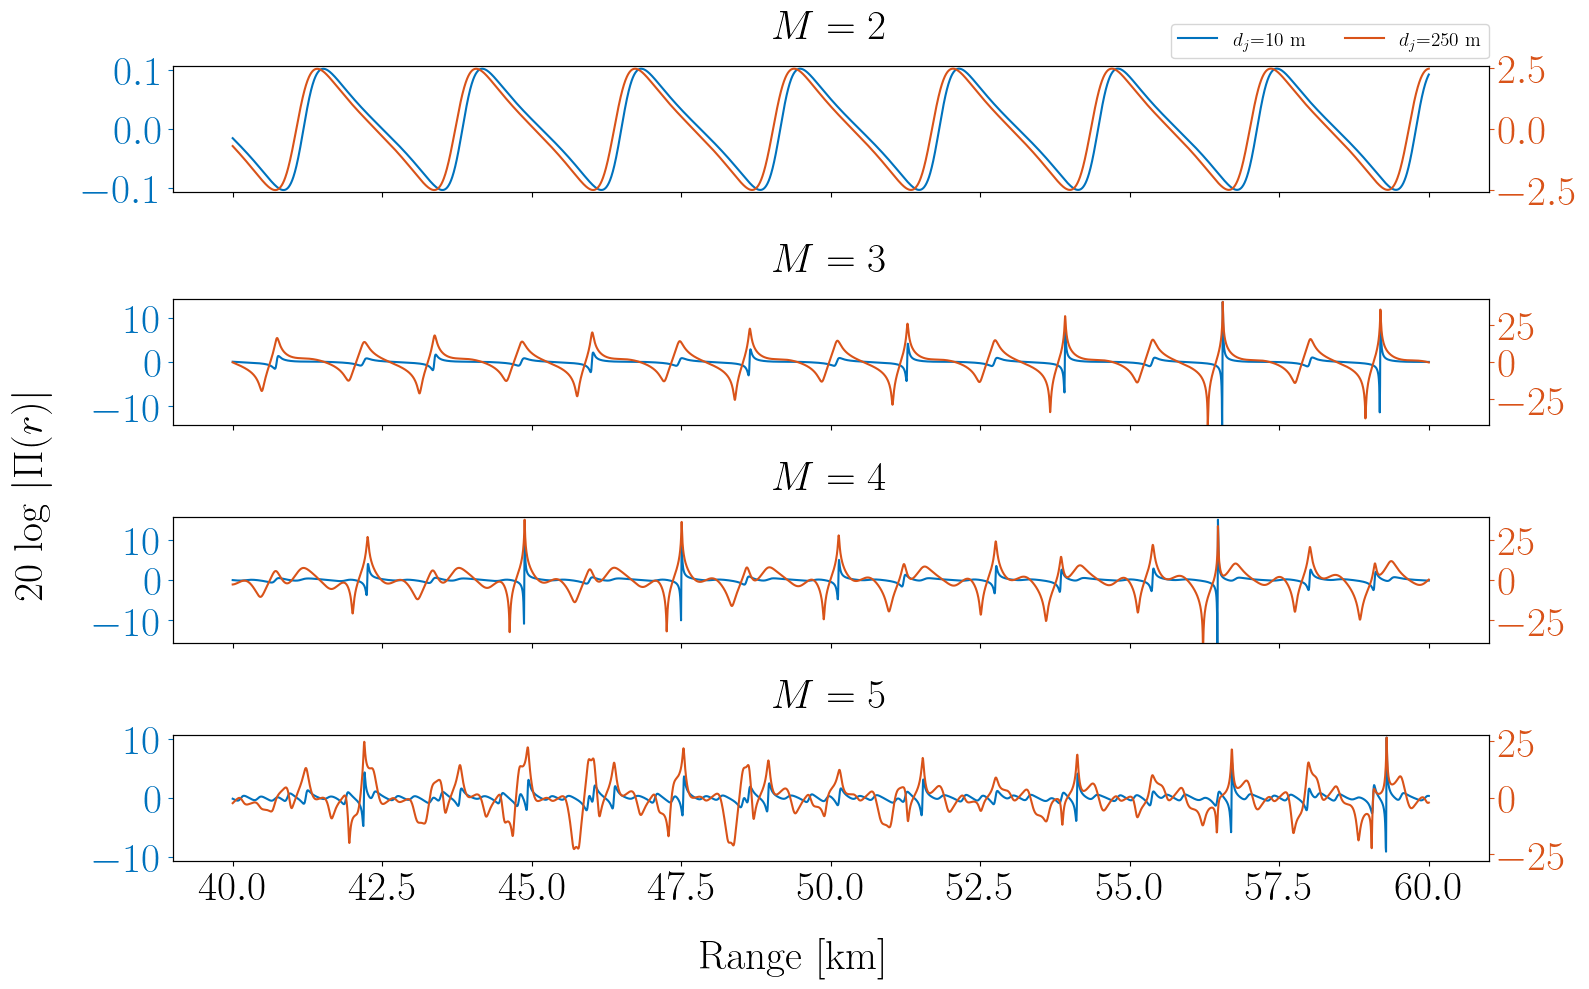

In [16]:
# Here we plot the amplitude of the RTF for two different receiver spacings and for variying number of modes in a subplot.

sfig = LargeFigure(size=(16, 10), legend_fontsize=12)

modes_to_plot = [2, 3, 4, 5]

fig, axs = plt.subplots(len(modes_to_plot), 1, sharex=True, sharey=False)
i_plot = 0
for m in modes_to_plot:
    i_m = modes.index(m)
    # Plot Pi for each freq at given number of modes
    pi = 20 * np.log10(np.abs(pi_12_r[i_m]))
    pi_bis = 20 * np.log10(np.abs(pi_12_r_bis[i_m]))
    r_pi = r_grid * 1e-3

    ax = axs[i_plot]
    ax.plot(
        r_pi,
        pi,
        label=rf"$d_j$={d12} m",
        color=color(0),
        linestyle="-",
        zorder=1,
    )

    # Copy axis to use different scale for the second curve
    ax_bis = ax.twinx()
    ax_bis.plot(
        r_pi,
        pi_bis,
        label=f"$d_j$={d12_bis} m",
        color=color(1),
        linestyle="-",
        zorder=2,
    )
    # Color the y-axis ticks
    ax.yaxis.label.set_color(color(0))
    ax_bis.yaxis.label.set_color(color(1))
    ax.tick_params(axis='y', colors=color(0))
    ax_bis.tick_params(axis="y", colors=color(1))

    # Set labels
    title = fr"$M = {{{m}}}$"
    ax.set_title(title)
    max_ax = np.max(pi) * 1.05
    ax.set_ylim([-max_ax, +max_ax])
    max_ax_bis = np.max(pi_bis) * 1.05
    ax_bis.set_ylim([-max_ax_bis, +max_ax_bis])
    # ax.set_xlim([30, 70])

    i_plot += 1

fig.supxlabel("Range [km]")
fig.supylabel(r"20 log $\lvert \Pi(r) \rvert $")

# Add legend annotations manually in the right top corner of the figure
lines_1, labels_1 = ax.get_legend_handles_labels()
lines_2, labels_2 = ax_bis.get_legend_handles_labels()
fig.legend(
    lines_1 + lines_2,
    labels_1 + labels_2,
    loc="upper right",
    fontsize=14,
    ncols=2,
    bbox_to_anchor=(0.94, 0.98),
)

# Save figures 
fpath = os.path.join(img_dir, f"Pi_j_vs_range_modes_comparison.png")
plt.savefig(fpath, dpi=300)

In [17]:
pi_12_r_crop = pi_12_r
pi_12_r_crop_abs = np.abs(pi_12_r_crop)
pi_12_r_crop_phase = np.angle(pi_12_r_crop)
# Bis
pi_12_r_crop_bis = pi_12_r_bis
pi_12_r_crop_abs_bis = np.abs(pi_12_r_crop_bis)
pi_12_r_crop_phase_bis = np.angle(pi_12_r_crop_bis)

# Remove mean
pi_12_r_crop_abs -= np.mean(pi_12_r_crop_abs, axis=-1, keepdims=True)
pi_12_r_crop_phase -= np.mean(pi_12_r_crop_phase, axis=-1, keepdims=True)
# Bis
pi_12_r_crop_abs_bis -= np.mean(pi_12_r_crop_abs_bis, axis=-1, keepdims=True)
pi_12_r_crop_phase_bis -= np.mean(pi_12_r_crop_phase_bis, axis=-1, keepdims=True)

# Apply FFT along range axis
pi_12_r_abs_fft = rfft(pi_12_r_crop_abs, axis=-1)
pi_12_r_phase_fft = rfft(pi_12_r_crop_phase, axis=-1)
# Bis
pi_12_r_abs_fft_bis = rfft(pi_12_r_crop_abs_bis, axis=-1)
pi_12_r_phase_fft_bis = rfft(pi_12_r_crop_phase_bis, axis=-1)

# Compute k_r
dr = r_grid[1] - r_grid[0]
k_r = rfftfreq(pi_12_r_crop.shape[-1], d=dr)

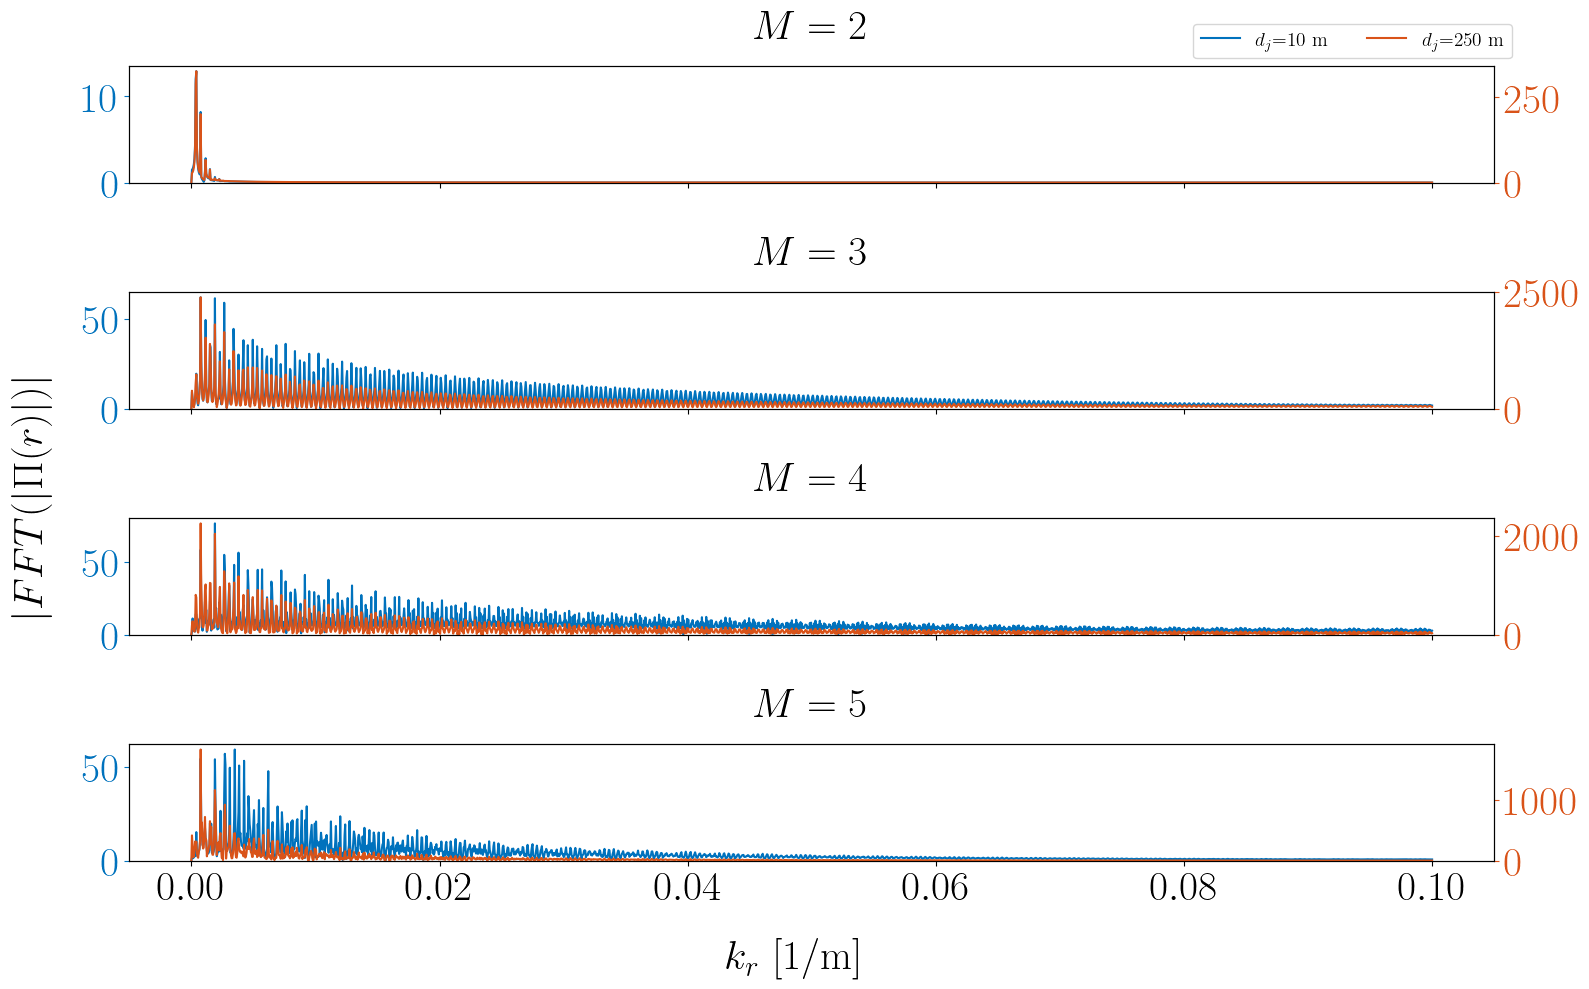

In [18]:
# Here we plot the amplitude of the FFT(RTF) for two different receiver spacings and for varying number of modes in a subplot.

sfig = LargeFigure(size=(16, 10), legend_fontsize=12)

modes_to_plot = [2, 3, 4, 5]

fig, axs = plt.subplots(len(modes_to_plot), 1, sharex=True, sharey=False)
i_plot = 0
for m in modes_to_plot:
    i_m = modes.index(m)

    # Plot
    ax = axs[i_plot]
    ax.plot(
        k_r,
        np.abs(pi_12_r_abs_fft[i_m]),
        label=rf"$d_j$={d12} m",
        color=color(0),
        linestyle="-",
        zorder=2,
    )
    # Copy axis to use different scale for the second curve
    ax_bis = ax.twinx()
    ax_bis.plot(
        k_r,
        np.abs(pi_12_r_abs_fft_bis[i_m]),
        label=f"$d_j$={d12_bis} m",
        color=color(1),
        linestyle="-",
        zorder=1,
    )
    title = fr"$M = {{{m}}}$"

    # Color the y-axis ticks
    ax.yaxis.label.set_color(color(0))
    ax_bis.yaxis.label.set_color(color(1))
    ax.tick_params(axis="y", colors=color(0))
    ax_bis.tick_params(axis="y", colors=color(1))

    # Set labels
    title = rf"$M = {{{m}}}$"
    ax.set_title(title)
    max_ax = np.max(np.abs(pi_12_r_abs_fft[i_m])) * 1.05
    ax.set_ylim([0, +max_ax])
    max_ax_bis = np.max(np.abs(pi_12_r_abs_fft_bis[i_m])) * 1.05
    ax_bis.set_ylim([0, +max_ax_bis])
    # ax.set_xlim([30, 70])

    i_plot += 1

fig.supxlabel(r"$k_r$ [1/m]")
fig.supylabel(r"$\lvert FFT(\lvert \Pi(r) \rvert) \rvert$")

# Add legend annotations manually in the right top corner of the figure
lines_1, labels_1 = ax.get_legend_handles_labels()
lines_2, labels_2 = ax_bis.get_legend_handles_labels()
fig.legend(
    lines_1 + lines_2,
    labels_1 + labels_2,
    loc="upper right",
    fontsize=14,
    ncols=2,
    bbox_to_anchor=(0.954, 0.98),
)

# Save figures
fpath = os.path.join(img_dir, f"fft_Pi_j_vs_range_modes_comparison.png")
plt.savefig(fpath, dpi=300)

In [19]:
mm = 1
nn = 2
a = ((mm - 1/2) * np.pi / D)**2
b = ((nn - 1 / 2) * np.pi / D) ** 2

def fx(a, b, x):
    return np.sqrt(x - a) - np.sqrt(x - b)

def fx_inv(a, b, y):
    x = ( a**2 - 2*a*b + b**2 + 2*a*y**2 + 2*b*y**2 + y**4 ) / (4*y**2)
    return x

k2 = fx_inv(a, b, y=2 * np.pi / d12)
flim = np.sqrt(k2) * g.c0 / (2 * np.pi)
print(flim)

75.4682259298574


In [20]:
kzm = (mm - 1/2) * np.pi / D
kzn = (nn - 1 / 2) * np.pi / D

freq = np.linspace(0.1, 100, 1000)
alpha_mn = 2 * (kzm**2 + kzn**2)
beta_mn = (kzm**2 - kzn**2)**2
k = 2 * np.pi * freq / g.c0
Delta = (alpha_mn/4 - k**2)**2 - beta_mn/4 

a_G = 1
b_G = -1 / 2 * alpha_mn
c_G = 1 / 2 * (kzm**4 + kzn**4)
Delta_G = b_G**2 - 4 * a_G * c_G
print(Delta_G)

def g_k(k, alpha_mn, kzm, kzn):
    return k**4 - (kzm**2 + kzn**2) * k**2 + kzm**2 * kzn**2

-3.896363641360096e-06


# Comparaison plusieurs fréquences

In [21]:
# Développement analytique asymptotique dans le cas M = 2 modes
from propa.ideal_waveguide import u_m
def Pi2_asympto_M2(r, d12, f, z_src, z_rcv, depth, bottom_bc):
    modes = np.array([1, 2])
    Am = u_m(modes, f, z_src, z_rcv, depth, bottom_bc=bottom_bc)

    delta_k12 = kr(1, f=f, depth=depth, bottom_bc=bottom_bc) - kr(
        2, f=f, depth=depth, bottom_bc=bottom_bc
    )
    a = Am[0] ** 2 + Am[1] ** 2 + 2 * Am[0] * Am[1] * np.cos(delta_k12 * (r + d12))
    b = Am[0] ** 2 + Am[1] ** 2 + 2 * Am[0] * Am[1] * np.cos(delta_k12 * r)
    Pi2_asympto = a / b
    return Pi2_asympto

In [22]:
nrgrid = 10000
rc = 50 * 1e3
delta_r = 1 * 1e3
rmin = (rc - delta_r / 2)
rmax = (rc + delta_r / 2)
r_grid = np.linspace(rmin, rmax, nrgrid)
r_grid_km = r_grid * 1e-3

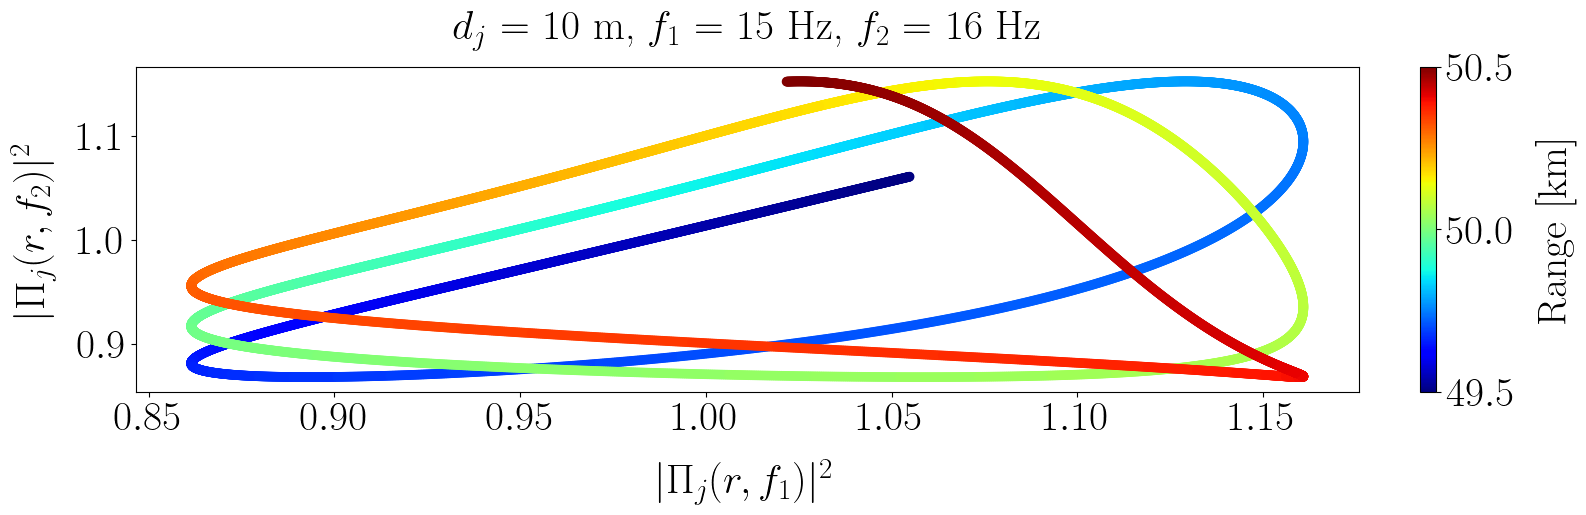

In [23]:
# Comparaison avec un développement analytique asymptotique dans le cas M = 2 modes
d = [10]
f1 = 15
f2 = 16

lfig = LargeFigure()
plt.figure()
for d12 in d:
    Pi_f1 = Pi2_asympto_M2(
        r=r_grid,
        d12=d12,
        f=f1,
        z_src=z_src,
        z_rcv=z_antenna,
        depth=D,
        bottom_bc=bottom_bc,
    )
    Pi_f2 = Pi2_asympto_M2(
        r=r_grid,
        d12=d12,
        f=f2,
        z_src=z_src,
        z_rcv=z_antenna,
        depth=D,
        bottom_bc=bottom_bc,
    )

    # plt.plot(Pi_f1, Pi_f2, label=f"d12 = {d12} m", linestyle="-", color="k")
    plt.scatter(Pi_f1, Pi_f2, c=r_grid_km, cmap="jet", linestyle="-", zorder=10)


# plt.legend()
plt.xlabel(r"$\lvert \Pi_j(r, f_1) \rvert^2$")
plt.ylabel(r"$\lvert \Pi_j(r, f_2) \rvert^2$")
plt.colorbar(label="Range [km]")
plt.title(rf"$d_{{j}}$ = {{{d12}}} m, $f_1$ = {f1} Hz, $f_2$ = {f2} Hz")

# Save figure
fig_path = os.path.join(
    img_dir,
    f"fPi2_dj{d12}m_f1{f1}Hz_f2{f2}Hz_M2.png",
)
plt.savefig(fig_path, dpi=300)

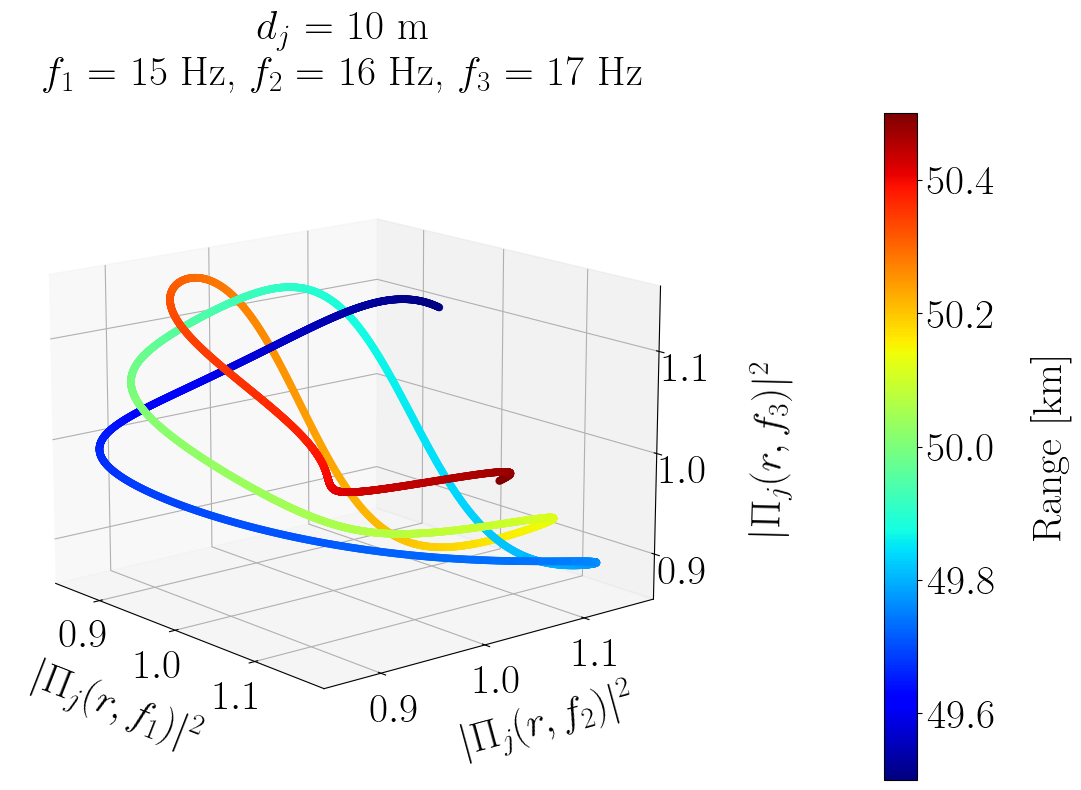

In [24]:
# Comparaison avec un développement analytique asymptotique dans le cas M = 2 modes
f1 = 15
f2 = 16
f3 = 17

# Create figure and 3D axis
# label_fontsize=24, title_fontsize=26, labelpad=15, ticks_fontsize=20, titlepad=5
lfig = PubFigure(labelpad=25)
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

for d12 in d:
    Pi_f1 = Pi2_asympto_M2(
        r=r_grid,
        d12=d12,
        f=f1,
        z_src=z_src,
        z_rcv=z_antenna,
        depth=D,
        bottom_bc=bottom_bc,
    )
    Pi_f2 = Pi2_asympto_M2(
        r=r_grid,
        d12=d12,
        f=f2,
        z_src=z_src,
        z_rcv=z_antenna,
        depth=D,
        bottom_bc=bottom_bc,
    )
    Pi_f3 = Pi2_asympto_M2(
        r=r_grid,
        d12=d12,
        f=f3,
        z_src=z_src,
        z_rcv=z_antenna,
        depth=D,
        bottom_bc=bottom_bc,
    )

    # Scatter plot with color mapping
    sc = ax.scatter3D(Pi_f1, Pi_f2, Pi_f3, c=r_grid_km, cmap="jet")
    plt.colorbar(sc, ax=ax, label="Range [km]", pad=0.15)

    # ax.plot(Pi_f1, Pi_f2, Pi_f3)

# Customization
ax.set_xlabel(r"$\lvert \Pi_j(r, f_1) \rvert^2$")
ax.set_ylabel(r"$\lvert \Pi_j(r, f_2) \rvert^2$")
ax.set_zlabel(r"$\lvert \Pi_j(r, f_3) \rvert^2$")
# ax.zaxis.labelpad=-0.7 # <- change the value here
ax.view_init(elev=15, azim=-40)  # Adjust view angle
plt.title(rf"$d_{{j}}$ = {{{d12}}} m" + "\n" + rf"  $f_1$ = {f1} Hz, $f_2$ = {f2} Hz, $f_3$ = {f3} Hz")

# Save figure
fig_path = os.path.join(
    img_dir,
    f"fPi3_dj{d12}m_f1{f1}Hz_f2{f2}Hz_f3{f3}Hz_M2.png",
)
plt.savefig(fig_path, dpi=300)

### Remarque 
La visualisation 3D dans le script .py permet de vérifier que cette courbe n'a pas d'intersection avec elle-même. L'application $f_{\Pi_3}$ est donc injective sur le petit intervalle en distance considéré.  

Text(0.5, 0.92, 'PCA (nc=3) of $\\lvert \\Pi(r, f) \\rvert^2$\n$f_1$ = 15 Hz, $f_2$ = 16 Hz, $f_3$ = 17 Hz\n$d_{j}$ = {10} m')

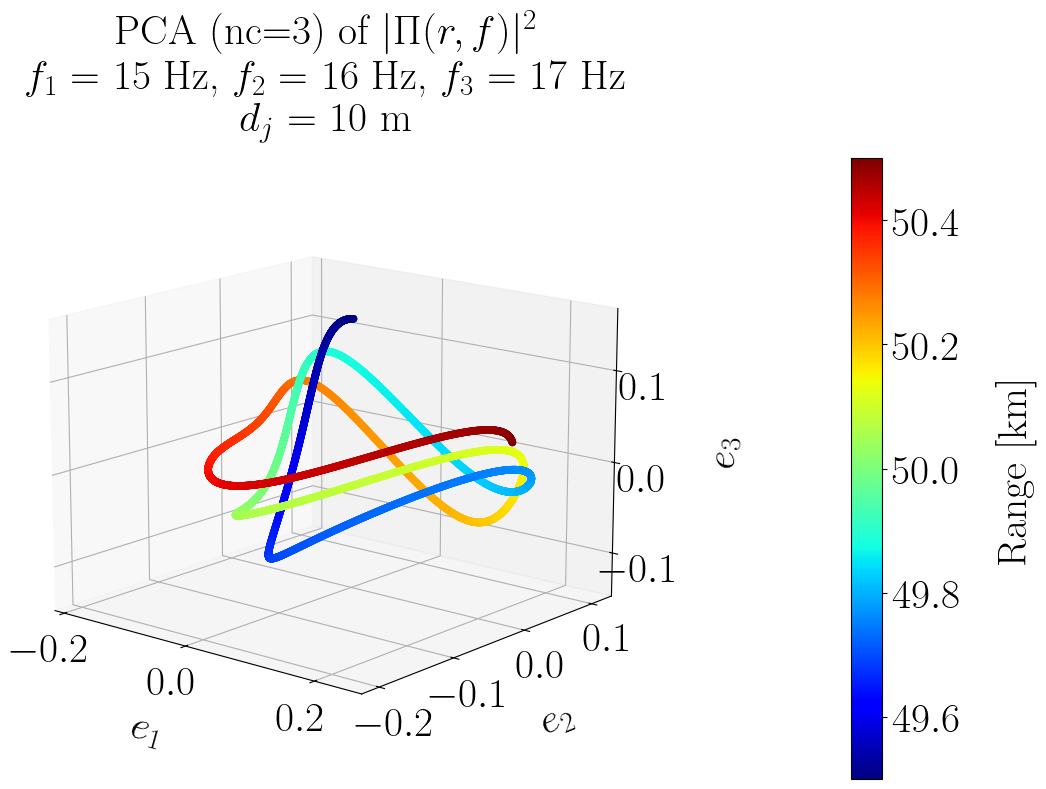

In [25]:
from sklearn.decomposition import PCA

data = np.array([Pi_f1, Pi_f2, Pi_f3]).T
X = PCA(n_components=3).fit_transform(data)


# Create figure and 3D axis
fig = plt.figure()
ax = fig.add_subplot(111, projection="3d")

# Scatter plot with color mapping
sc = ax.scatter3D(X[:, 0], X[:, 1], X[:, 2], c=r_grid_km, cmap="jet")
plt.colorbar(sc, ax=ax, label="Range [km]", pad=0.15)

# Customization
ax.view_init(elev=15, azim=-50)  # Adjust view angle

ax.set_xlabel(r"$e_1$")
ax.set_ylabel(r"$e_2$")
ax.set_zlabel(r"$e_3$")
plt.title(rf"PCA (nc=3) of $\lvert \Pi(r, f) \rvert^2$"+ "\n" + fr"$f_1$ = {f1} Hz, $f_2$ = {f2} Hz, $f_3$ = {f3} Hz" + "\n" + rf"$d_{{j}}$ = {{{d12}}} m")

In [ ]:
from sklearn.decomposition import PCA

data = np.array([Pi_f1, Pi_f2, Pi_f3]).T
X = PCA(n_components=2).fit_transform(data)


# Create figure and 3D axis
plt.figure(figsize=(8, 6))

# Scatter plot with color mapping
plt.scatter(X[:, 0], X[:, 1], c=r_grid_km, cmap="jet")

plt.colorbar(label="Range [km]")
plt.xlabel(r"$e_1$")
plt.ylabel(r"$e_2$")

plt.title(rf"PCA (nc=2) of $\lvert \Pi(r, f) \rvert^2$"+ "\n" + fr"$f_1$ = {f1} Hz, $f_2$ = {f2} Hz, $f_3$ = {f3} Hz" + "\n" + rf"$d_{{j}}$ = {{{d12}}} m")

In [ ]:
data = np.array([Pi_f1, Pi_f2, Pi_f3]).T
X = PCA(n_components=1).fit_transform(data)

# Create figure and 3D axis
plt.figure(figsize=(8, 6))

# Scatter plot with color mapping
sc = plt.plot(
    r_grid_km,
    X[:, 0],
)

# plt.colorbar(sc, "Range [km]")
plt.xlabel("Range [km]")
plt.ylabel(r"$e_1$")

plt.title(rf"PCA (nc=1) of $\lvert \Pi(r, f) \rvert^2$"+ "\n" + fr"$f_1$ = {f1} Hz, $f_2$ = {f2} Hz, $f_3$ = {f3} Hz" + "\n" + rf"$d_{{j}}$ = {{{d12}}} m")

In [ ]:
# Avec un nombre très important de fréquence
freqs = np.linspace(12, 18, 201)

Pi_f = []
for fi in freqs:
    Pi_fi = Pi2_asympto_M2(
        r=r_grid,
        d12=d12,
        f=fi,
        z_src=z_src,
        z_rcv=z_antenna,
        depth=D,
        bottom_bc=bottom_bc,
    )
    Pi_fi = Pi_fi / np.max(np.abs(Pi_fi))
    Pi_f.append(Pi_fi)

Pi_f = np.array(Pi_f)  # nfreqs x nranges

data = Pi_f.T  # nranges x nfreqs
X_pca = PCA(n_components=1).fit_transform(data)     # Only one degree of freedom = r 

from sklearn.decomposition import KernelPCA
kernel_pca = KernelPCA(n_components=1, kernel="poly")
X_kernel_pca = kernel_pca.fit(data).transform(data)

# Create figure and 3D axis
plt.figure(figsize=(8, 6))
plt.plot(
    colors,
    X_pca[:, 0],
    label="PCA",
)
plt.plot(
    colors,
    X_kernel_pca[:, 0],
    label="Kernel PCA (RBF)",
)
plt.xlabel("Range [km]")
plt.ylabel(r"$e_1$")
plt.legend(fontsize=12)

plt.title(rf"PCA (nc=1) of $\lvert \Pi(r, f) \rvert^2$"+ "\n" + fr"$f$ = [12 Hz, 18 Hz] (nf = {{{freqs.size}}})" + "\n" + rf"$d_{{12}}$ = {{{d12}}} m")

In [ ]:
data = Pi_f.T  # nranges x nfreqs
n_components = 2
X_pca = PCA(n_components=n_components).fit_transform(data)  # Only one degree of freedom = r
from sklearn.decomposition import KernelPCA

kernel_pca = KernelPCA(n_components=n_components, kernel="linear")
X_kernel_pca = kernel_pca.fit(data).transform(data)

# Create figure and 3D axis
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(16, 6))

# Scatter plot with color mapping
sc = axs[0].scatter(X_pca[:, 0], X_pca[:, 1], c=colors, cmap="jet")
sc = axs[1].scatter(X_kernel_pca[:, 0], X_kernel_pca[:, 1], c=colors, cmap="jet")


# plt.colorbar(sc, ax=axs[0], label="Range [km]")
plt.colorbar(sc, ax=axs[1], label="Range [km]")

axs[0].set_xlabel(r"$e_1$")
axs[0].set_ylabel(r"$e_2$")
axs[1].set_xlabel(r"$e_1$")
axs[1].set_ylabel(r"$e_2$")

In [ ]:
from sklearn.preprocessing import MinMaxScaler

def plot_embedding(X, title):
    _, ax = plt.subplots()
    X = MinMaxScaler().fit_transform(X)
    ax.plot(r_grid * 1e-3, X[:, 0])
    ax.set_title(title)
    ax.set_xlabel("Range [km]")
    ax.set_ylabel(r"$e_1$")

In [ ]:
data = Pi_f.T  # nranges x nfreqs



# digits = load_digits(n_class=6)
# X, y = digits.data, digits.target
# n_samples, n_features = X.shape
# n_neighbors = 30

# X, y = digits.data, digits.target
X = data    
y = None
n_samples, n_features = X.shape
n_neighbors = 30
n_components = 1



from sklearn.decomposition import TruncatedSVD
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.ensemble import RandomTreesEmbedding
from sklearn.manifold import (
    MDS,
    TSNE,
    Isomap,
    LocallyLinearEmbedding,
    SpectralEmbedding,
)
from sklearn.neighbors import NeighborhoodComponentsAnalysis
from sklearn.pipeline import make_pipeline
from sklearn.random_projection import SparseRandomProjection


embeddings = {
    "Random projection embedding": SparseRandomProjection(
        n_components=n_components, random_state=42
    ),
    "Truncated SVD embedding": TruncatedSVD(n_components=n_components),
    # "Linear Discriminant Analysis embedding": LinearDiscriminantAnalysis(
    #     n_components=n_components
    # ),
    "Isomap embedding": Isomap(n_neighbors=n_neighbors, n_components=n_components),
    # "Standard LLE embedding": LocallyLinearEmbedding(
    #     n_neighbors=n_neighbors, n_components=n_components, method="standard"
    # ),
    # "Modified LLE embedding": LocallyLinearEmbedding(
    #     n_neighbors=n_neighbors, n_components=n_components, method="modified"
    # ),
    # "Hessian LLE embedding": LocallyLinearEmbedding(
    #     n_neighbors=n_neighbors, n_components=n_components, method="hessian"
    # ),
    # "LTSA LLE embedding": LocallyLinearEmbedding(
    #     n_neighbors=n_neighbors, n_components=n_components, method="ltsa"
    # ),
    # "MDS embedding": MDS(n_components=n_components, n_init=1, max_iter=120, eps=1e-6),
    # "Random Trees embedding": make_pipeline(
    #     RandomTreesEmbedding(n_estimators=200, max_depth=5, random_state=0),
    #     TruncatedSVD(n_components=n_components),
    # ),
    # "Spectral embedding": SpectralEmbedding(
    #     n_components=n_components, random_state=0, eigen_solver="arpack"
    # ),
    # "t-SNE embedding": TSNE(
    #     n_components=n_components,
    #     max_iter=500,
    #     n_iter_without_progress=150,
    #     n_jobs=2,
    #     random_state=0,
    # ),
    # "NCA embedding": NeighborhoodComponentsAnalysis(
    #     n_components=n_components, init="pca", random_state=0
    # ),
}



In [ ]:
from time import time

projections, timing = {}, {}
for name, transformer in embeddings.items():
    if name.startswith("Linear Discriminant Analysis"):
        data = X.copy()
        data.flat[:: X.shape[1] + 1] += 0.01  # Make X invertible
    else:
        data = X

    print(f"Computing {name}...")
    start_time = time()
    projections[name] = transformer.fit_transform(data, y)
    # projections[name] = transformer.fit_transform(data)

    timing[name] = time() - start_time


for name in timing:
    title = f"{name} (time {timing[name]:.3f}s)"
    plot_embedding(projections[name], title)

plt.show()

In [ ]:
# Isomap on a wider range of distances
nrgrid = 10000
rc = 20 * 1e3
delta_r = 30 * 1e3
rmin = rc - delta_r / 2
rmax = rc + delta_r / 2
r_grid = np.linspace(rmin, rmax, nrgrid)
colors = r_grid * 1e-3

# Avec un nombre très important de fréquence
freqs = np.linspace(12, 18, 101)

Pi_f = []
for fi in freqs:
    Pi_fi = Pi2_asympto_M2(
        r=r_grid,
        d12=d12,
        f=fi,
        z_src=z_src,
        z_rcv=z_antenna,
        depth=D,
        bottom_bc=bottom_bc,
    )
    Pi_fi = Pi_fi / np.max(np.abs(Pi_fi))
    Pi_f.append(Pi_fi)

Pi_f = np.array(Pi_f)  # nfreqs x nranges

data = Pi_f.T  # nranges x nfreqs
X = data
y = None
n_samples, n_features = X.shape
n_neighbors = 30
n_components = 1


embeddings = {
    "Isomap embedding": Isomap(n_neighbors=n_neighbors, n_components=n_components),
}

projections, timing = {}, {}
for name, transformer in embeddings.items():
    if name.startswith("Linear Discriminant Analysis"):
        data = X.copy()
        data.flat[:: X.shape[1] + 1] += 0.01  # Make X invertible
    else:
        data = X

    print(f"Computing {name}...")
    start_time = time()
    projections[name] = transformer.fit_transform(data, y)
    # projections[name] = transformer.fit_transform(data)

    timing[name] = time() - start_time


for name in timing:
    title = f"{name} (time {timing[name]:.3f}s)"
    plot_embedding(projections[name], title)

plt.show()

In [ ]:
# Comparaison de la représentation du plan (Pi(f1), Pi(f2)) et de la projection sur le vecteur e1 trouvé par isomap
# pour le même couple de fréquence f1 f2

nrgrid = 10000
rc = 20 * 1e3
delta_r = 2 * 1e3
rmin = rc - delta_r / 2
rmax = rc + delta_r / 2
r_grid = np.linspace(rmin, rmax, nrgrid)
colors = r_grid * 1e-3

f1, f2 = 40, 50
freqs = [f1, f2]

lfig = LargeFigure()
plt.figure()

d12 = 100
Pi_f1 = Pi2_asympto_M2(
    r=r_grid,
    d12=d12,
    f=f1,
    z_src=z_src,
    z_rcv=z_antenna,
    depth=D,
    bottom_bc=bottom_bc,
)
Pi_f2 = Pi2_asympto_M2(
    r=r_grid,
    d12=d12,
    f=f2,
    z_src=z_src,
    z_rcv=z_antenna,
    depth=D,
    bottom_bc=bottom_bc,
)

plt.scatter(Pi_f1, Pi_f2, c=colors, cmap="jet", linestyle="-", zorder=10)


# plt.legend()
plt.xlabel(r"$\lvert \Pi(r, f_1) \rvert^2$")
plt.ylabel(r"$\lvert \Pi(r, f_2) \rvert^2$")
plt.colorbar(label="Range [km]")
plt.title(rf"$d_{{12}}$ = {{{d12}}} m, $f_1$ = {f1} Hz, $f_2$ = {f2} Hz")


Pi_f = np.array([Pi_f1, Pi_f2])
data = Pi_f.T  # nranges x nfreqs
X = data
y = None
n_samples, n_features = X.shape
n_neighbors = 30
n_components = 1

embeddings = {
    "Isomap embedding": Isomap(n_neighbors=n_neighbors, n_components=n_components),
}

projections, timing = {}, {}
for name, transformer in embeddings.items():
    if name.startswith("Linear Discriminant Analysis"):
        data = X.copy()
        data.flat[:: X.shape[1] + 1] += 0.01  # Make X invertible
    else:
        data = X

    print(f"Computing {name}...")
    start_time = time()
    projections[name] = transformer.fit_transform(data, y)
    # projections[name] = transformer.fit_transform(data)

    timing[name] = time() - start_time



In [ ]:
plt.figure()
for name in timing:
    title = f"{name} (time {timing[name]:.3f}s)"
    # plot_embedding(projections[name], title)

    X_ = MinMaxScaler().fit_transform(projections[name])
    plt.plot(r_grid * 1e-3, X_[:, 0])

plt.plot(r_grid * 1e-3, (Pi_f1 + Pi_f2) / np.max(Pi_f1 + Pi_f2))
plt.title(title)
plt.xlabel("Range [km]")
plt.ylabel(r"$e_1$")

# plt.legend(fontsize=12)
plt.show()

In [ ]:
# Avec un nombre très important de fréquence
proj_nf = []
nf = [2, 5, 10, 50, 100]
for nf_i in nf:
    freqs = np.linspace(40, 50, nf_i)

    Pi_f = []
    for fi in freqs:
        Pi_fi = Pi2_asympto_M2(
            r=r_grid,
            d12=d12,
            f=fi,
            z_src=z_src,
            z_rcv=z_antenna,
            depth=D,
            bottom_bc=bottom_bc,
        )
        Pi_fi = Pi_fi / np.max(np.abs(Pi_fi))
        Pi_f.append(Pi_fi)

    Pi_f = np.array(Pi_f)  # nfreqs x nranges
    Pi_f = 10 * np.log10(Pi_f)
    
    data = Pi_f.T  # nranges x nfreqs
    X = data
    y = None
    n_samples, n_features = X.shape
    n_neighbors = 30
    n_components = 1

    embeddings = {
        "Isomap embedding": Isomap(n_neighbors=n_neighbors, n_components=n_components),
    }

    projections, timing = {}, {}
    for name, transformer in embeddings.items():
        if name.startswith("Linear Discriminant Analysis"):
            data = X.copy()
            data.flat[:: X.shape[1] + 1] += 0.01  # Make X invertible
        else:
            data = X

        print(f"Computing {name}...")
        start_time = time()
        projections[name] = transformer.fit_transform(data, y)
        # projections[name] = transformer.fit_transform(data)

        timing[name] = time() - start_time

    proj_nf.append(projections)

In [ ]:
# nf = [2, 5, 10, 50, 100]

plt.figure()
for i_nf, projections in enumerate(proj_nf):
    for name in timing:
        title = f"{name} (time {timing[name]:.3f}s)"
        # plot_embedding(projections[name], title)

        X_ = MinMaxScaler().fit_transform(projections[name])
        plt.plot(r_grid * 1e-3, X_[:, 0], label=f"nf={nf[i_nf]}")

plt.title(title)
plt.xlabel("Range [km]")
plt.ylabel(r"$e_1$")

plt.legend(fontsize=12)
plt.show()

In [ ]:
r_grid1 = r_grid
r_grid2 = r_grid + d12

nf = [2, 5, 10, 50, 100]
for nf_i in nf:
    freqs = np.linspace(40, 50, nf_i)

    Pi_f = []
    for fi in freqs:
        Pi_fi = Pi2_asympto_M2(
            r=r_grid,
            d12=d12,
            f=fi,
            z_src=z_src,
            z_rcv=z_antenna,
            depth=D,
            bottom_bc=bottom_bc,
        )
        Pi_fi = Pi_fi / np.max(np.abs(Pi_fi))
        Pi_f.append(Pi_fi)

    Pi_f_1 = 10*np.log10(np.array(Pi_f))  # nfreqs x nranges

    ff, rr, zz, p_field1 = field(
        f=freqs,
        z_src=z_antenna,
        z=z_src,
        r=r_grid1,
        depth=D,
        bottom_bc=bottom_bc,
        n=3,
    )
    ff, _, _, p_field2 = field(
        f=freqs,
        z_src=z_antenna,
        z=z_src,
        r=r_grid2,
        depth=D,
        bottom_bc=bottom_bc,
        n=3,
    )
    p_field2[(p_field2 == 0) | np.isnan(p_field2)] = 1e-20
    p_field1[(p_field1 == 0) | np.isnan(p_field1)] = 1e-20
    Pi_f = p_field2 / p_field1
    Pi_f = Pi_f.squeeze()  # nfreqs x nranges
    Pi_f = np.abs(Pi_f) ** 2
    Pi_f_2 = Pi_f / np.max(np.abs(Pi_f), axis=1).reshape(Pi_f.shape[0], 1)
    Pi_f_2 = 10 * np.log10(Pi_f_2)
    print(np.allclose(Pi_f_1, Pi_f_2))
    plt.figure()
    plt.plot(r_grid, Pi_f_2[0, :], label="2")
    plt.plot(r_grid, Pi_f_1[0, :], label="1", linestyle="--")

In [ ]:
# Avec un nombre très important de fréquence
r_grid1 = r_grid
r_grid2 = r_grid + d12
# modes = [2, 3, 4, 5]
modes = [3, 4]

# nf = [2, 5, 10, 50, 100]
nf = [1000]

fcutoff_M = (np.max(modes) - 1/2) * g.c0 / (2 * D)
print(fcutoff_M)
# fmin =
proj_n_nf = []
for n in modes :
    proj_nf = []
    for nf_i in nf:
        freqs = np.linspace(40, 60, nf_i)

        ff, rr, zz, p_field1 = field(
            f=freqs, z_src=z_antenna, z=z_src, r=r_grid1, depth=D, bottom_bc=bottom_bc, n=n
        )
        ff, _, _, p_field2 = field(
            f=freqs,
            z_src=z_antenna,
            z=z_src,
            r=r_grid2,
            depth=D,
            bottom_bc=bottom_bc,
            n=n,
        )
        p_field2[(p_field2 == 0) | np.isnan(p_field2)] = 1e-20
        p_field1[(p_field1 == 0) | np.isnan(p_field1)] = 1e-20
        Pi_f = p_field2 / p_field1
        Pi_f = Pi_f.squeeze()  # nfreqs x nranges
        Pi_f = np.abs(Pi_f) ** 2
        Pi_f = Pi_f / np.max(np.abs(Pi_f), axis=1).reshape(Pi_f.shape[0], 1)
        Pi_f = 10*np.log10(Pi_f)
        
        data = Pi_f.T  # nranges x nfreqs
        X = data
        y = None
        n_samples, n_features = X.shape
        n_neighbors = 30
        n_components = 1

        embeddings = {
            "Isomap embedding": Isomap(n_neighbors=n_neighbors, n_components=n_components),
        }

        projections, timing = {}, {}
        for name, transformer in embeddings.items():
            if name.startswith("Linear Discriminant Analysis"):
                data = X.copy()
                data.flat[:: X.shape[1] + 1] += 0.01  # Make X invertible
            else:
                data = X

            print(f"Computing {name}...")
            start_time = time()
            projections[name] = transformer.fit_transform(data, y)
            # projections[name] = transformer.fit_transform(data)

            timing[name] = time() - start_time

        proj_nf.append(projections)
    proj_n_nf.append(proj_nf)

In [ ]:
for i_n, n in enumerate(modes):
    plt.figure()
    proj_nf = proj_n_nf[i_n]
    for i_nf, projections in enumerate(proj_nf):
        for name in timing:
            title = f"{name} (time {timing[name]:.3f}s) - modes 1 to {n}"
            # plot_embedding(projections[name], title)

            X_ = MinMaxScaler().fit_transform(projections[name])
            plt.plot(r_grid1 * 1e-3, X_[:, 0], label=f"nf={nf[i_nf]}")
    plt.title(title)
    plt.xlabel("Range [km]")
    plt.ylabel(r"$e_1$")

    plt.legend(fontsize=12)
    plt.show()

In [ ]:
# Create figure and 3D axis
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")

modes = [2]

for d12 in d:
    __, __, Pi_f1 = pi_12_modes(
        f=f1,
        z_antenna=z_antenna,
        z_grid=z_src,
        r_grid=r_grid,
        d12=d12,
        depth=D,
        bottom_bc=bottom_bc,
        modes=modes,
    )
    _, _, Pi_f2 = pi_12_modes(
        f=f2,
        z_antenna=z_antenna,
        z_grid=z_src,
        r_grid=r_grid,
        d12=d12,
        depth=D,
        bottom_bc=bottom_bc,
        modes=modes,
    )
    _, _, Pi_f3 = pi_12_modes(
        f=f3,
        z_antenna=z_antenna,
        z_grid=z_src,
        r_grid=r_grid,
        d12=d12,
        depth=D,
        bottom_bc=bottom_bc,
        modes=modes,
    )
    Pi_f1 = np.abs(Pi_f1) ** 2
    Pi_f2 = np.abs(Pi_f2) ** 2
    Pi_f3 = np.abs(Pi_f3) ** 2
    # Pi_f1 = np.abs(Pi_f1)
    # Pi_f2 = np.abs(Pi_f2)
    # Pi_f3 = np.abs(Pi_f3)

    # Scatter plot with color mapping
    sc = ax.scatter3D(Pi_f1, Pi_f2, Pi_f3, c=colors, cmap="jet")
    plt.colorbar(sc, ax=ax, label="Range [km]")

    ax.plot(Pi_f1, Pi_f2, Pi_f3)


# Customization
ax.view_init(elev=15, azim=60)  # Adjust view angle

ax.set_xlabel(r"$\lvert \Pi(r, f_1) \rvert^2$")
ax.set_ylabel(r"$\lvert \Pi(r, f_2) \rvert^2$")
ax.set_zlabel(r"$\lvert \Pi(r, f_3) \rvert^2$")

In [ ]:
# Create figure and 3D axis
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")

modes = [2]

for d12 in d:
    __, __, Pi_f1 = pi_12_modes(
        f=f1,
        z_antenna=z_antenna,
        z_grid=z_src,
        r_grid=r_grid,
        d12=d12,
        depth=D,
        bottom_bc=bottom_bc,
        modes=modes,
    )
    _, _, Pi_f2 = pi_12_modes(
        f=f2,
        z_antenna=z_antenna,
        z_grid=z_src,
        r_grid=r_grid,
        d12=d12,
        depth=D,
        bottom_bc=bottom_bc,
        modes=modes,
    )
    _, _, Pi_f3 = pi_12_modes(
        f=f3,
        z_antenna=z_antenna,
        z_grid=z_src,
        r_grid=r_grid,
        d12=d12,
        depth=D,
        bottom_bc=bottom_bc,
        modes=modes,
    )
    Pi_f1 = np.angle(Pi_f1)
    Pi_f2 = np.angle(Pi_f2)
    Pi_f3 = np.angle(Pi_f3)

    # Scatter plot with color mapping
    sc = ax.scatter3D(Pi_f1, Pi_f2, Pi_f3, c=colors, cmap="jet")
    plt.colorbar(sc, ax=ax, label="Range [km]")

    ax.plot(Pi_f1, Pi_f2, Pi_f3)


# Customization
ax.view_init(elev=15, azim=60)  # Adjust view angle

ax.set_xlabel(r"$\phi (\Pi(r, f_1))$")
ax.set_ylabel(r"$\phi (\Pi(r, f_2))$")
ax.set_zlabel(r"$\phi (\Pi(r, f_3))$")

In [ ]:
# Create figure and 3D axis

f1, f2, f3 = 15, 20, 100
modes = [13]

for d12 in d:
    for fi in [f1, f2, f3]:

        fig = plt.figure(figsize=(8, 6))
        __, __, Pi_f1 = pi_12_modes(
            f=fi,
            z_antenna=z_antenna,
            z_grid=z_src,
            r_grid=r_grid,
            d12=d12,
            depth=D,
            bottom_bc=bottom_bc,
            modes=modes,
        )

        Pi_f1_phi = np.angle(Pi_f1)
        Pi_f1_mod= np.abs(Pi_f1)

        # Scatter plot with color mapping
        plt.scatter(
            Pi_f1_mod, Pi_f1_phi, c=colors, cmap="jet", linestyle="-", zorder=10
        )
        plt.ylabel(r"$\phi (\Pi(r, f_1))$")
        plt.xlabel(r"$\lvert \Pi(r, f_1) \rvert$")
        plt.colorbar(label="Range [km]")

In [ ]:
# Create figure and 3D axis
fig = plt.figure()
ax = fig.add_subplot(111, projection="3d")

f1, f2 = 15, 16
modes = [2]

for d12 in d:
    __, __, Pi_f1 = pi_12_modes(
        f=f1,
        z_antenna=z_antenna,
        z_grid=z_src,
        r_grid=r_grid,
        d12=d12,
        depth=D,
        bottom_bc=bottom_bc,
        modes=modes,
    )
    _, _, Pi_f2 = pi_12_modes(
        f=f2,
        z_antenna=z_antenna,
        z_grid=z_src,
        r_grid=r_grid,
        d12=d12,
        depth=D,
        bottom_bc=bottom_bc,
        modes=modes,
    )

    Pi_f1_mod = np.abs(Pi_f1)
    Pi_f1_arg = np.angle(Pi_f1)
    Pi_f2_mod = np.abs(Pi_f2)
    Pi_f2_arg = np.angle(Pi_f2)

    # Scatter plot with color mapping
    sc = ax.scatter3D(Pi_f1_mod, Pi_f1_arg, Pi_f2_mod, c=colors, cmap="jet")
    # sc = ax.scatter3D(Pi_f1_mod, Pi_f1_arg, Pi_f2_arg, c=colors, cmap="jet")
    # sc = ax.plot3D(Pi_f1_mod, Pi_f1_arg, Pi_f2_arg)

    plt.colorbar(sc, ax=ax, label="Range [km]")


# Customization
ax.view_init(elev=15, azim=120)  # Adjust view angle

ax.set_xlabel(r"$\lvert \Pi(r, f_1) \rvert$")
ax.set_ylabel(r"$\phi (\Pi(r, f_1))$")
ax.set_zlabel(r"$\lvert \Pi(r, f_2) \rvert$")

**Remarque**
 
Le terme oscillant semble dépendre du nombre d'onde horizontal $k_{rm}$ et de la longueur d'onde associée : 
$$
\lambda_{rm} = \frac{2\pi}{k_{rm}}
$$ 
où 
$$
    k_{rm} = \sqrt{ k^2 - k_{zm}^2}
$$

avec, 

$$ 
k_{zm} =  (m - \frac{1}{2}) \frac{\pi}{D}, \quad m \in \mathbb{N}^{*} .
$$
           


